<a href="https://colab.research.google.com/github/MishaE-e/ml_fmi/blob/main/7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Набор данных: https://www.kaggle.com/datasets/yasserh/twitter-tweets-sentiment-dataset

In [ ]:
!pip install scikit-learn pandas numpy nltk matplotlib wordcloud gensim lime tensorflow keras

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import TruncatedSVD
from nltk.tokenize import RegexpTokenizer
import warnings
warnings.filterwarnings('ignore')

Загрузка данных

In [ ]:
df = pd.read_csv('Tweets.csv')

Структура

In [ ]:
print(f"Размер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")
print(f"Первые 5 строк:")
df.head()

Размер датасета: (27481, 4)
Колонки: ['textID', 'text', 'selected_text', 'sentiment']
Первые 5 строк:


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


Проверка на пропуски

In [ ]:
print(f"Пропуски в данных:\n{df.isnull().sum()}")
df = df.dropna(subset=['text', 'sentiment'])
print(f"После удаления пропусков: {df.shape}")

Пропуски в данных:
textID           0
text             1
selected_text    1
sentiment        0
dtype: int64
После удаления пропусков: (27480, 4)


Длина твитов

Статистика длины твитов:
Минимум: 3
Максимум: 141
Среднее: 68.3
Медиана: 64.0


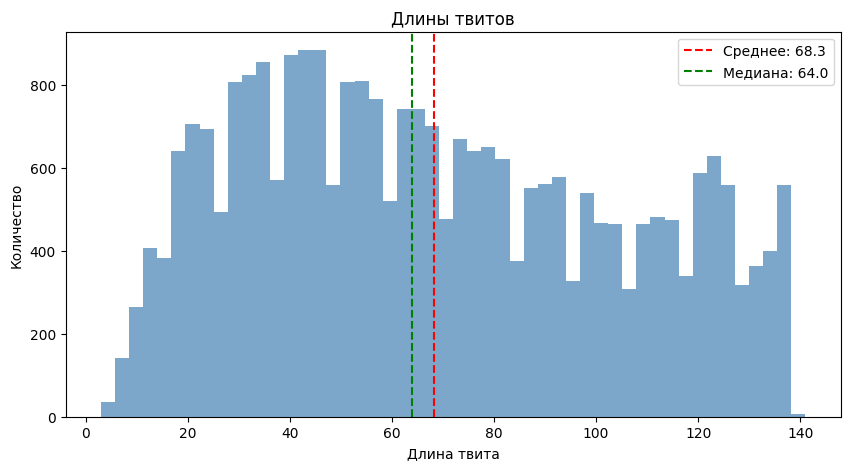

In [ ]:
df['text_length'] = df['text'].astype(str).apply(len)
print(f"Статистика длины твитов:")
print(f"Минимум: {df['text_length'].min()}")
print(f"Максимум: {df['text_length'].max()}")
print(f"Среднее: {df['text_length'].mean():.1f}")
print(f"Медиана: {df['text_length'].median():.1f}")

plt.figure(figsize=(10, 5))
plt.hist(df['text_length'], bins=50, alpha=0.7, color='steelblue')
plt.axvline(df['text_length'].mean(), color='red', linestyle='dashed', label=f'Среднее: {df["text_length"].mean():.1f}')
plt.axvline(df['text_length'].median(), color='green', linestyle='dashed', label=f'Медиана: {df["text_length"].median():.1f}')
plt.xlabel('Длина твита')
plt.ylabel('Количество')
plt.title('Длины твитов')
plt.legend()

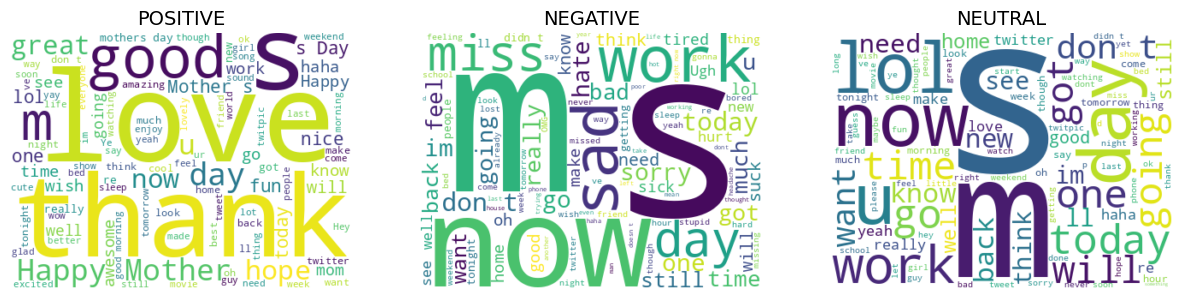

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, sentiment in enumerate(['positive', 'negative', 'neutral']):
    sentiment_text = ' '.join(df[df['sentiment'] == sentiment]['text'].astype(str).tolist())
    if sentiment_text:
        wordcloud = WordCloud(width=400, height=300, background_color='white', max_words=100).generate(sentiment_text)
        axes[idx].imshow(wordcloud, interpolation='bilinear')
        axes[idx].axis('off')
        axes[idx].set_title(f'{sentiment.upper()}', fontsize=14)

Работа с данными

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return

    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

tokenizer = RegexpTokenizer(r'\w+')
df['tokens'] = df['clean_text'].apply(tokenizer.tokenize)

df = df[df['clean_text'] != '']
df = df[df['tokens'].apply(len) > 0]

print(f"После очистки: {df.shape}")

print(f"Оригинал: {df['text'].iloc[24]}")
print(f"Очищенный: {df['clean_text'].iloc[24]}")
print(f"Тональность: {df['sentiment'].iloc[24]}")

После очистки: (27476, 7)
Оригинал: SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cALLed LoSe f0LloWeRs FridAy... smH
Очищенный: see wat i mean bout follw friidays its called lose fllowers friday smh
Тональность: neutral


In [ ]:
sentiment_map = {'positive': 0, 'negative': 1, 'neutral': 2}
df['label'] = df['sentiment'].map(sentiment_map)

X = df['clean_text'].tolist()
y = df['label'].tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size: {len(X_test)}")
print(f"Распределение классов в train:\n{pd.Series(y_train).value_counts()}")
print(f"Распределение классов в test:\n{pd.Series(y_test).value_counts()}")

label_to_text = {0: 'positive', 1: 'negative', 2: 'neutral'}

Train size: 21980
Test size: 5496
Распределение классов в train:
2    8891
0    6865
1    6224
Name: count, dtype: int64
Распределение классов в test:
2    2223
0    1717
1    1556
Name: count, dtype: int64


Размерность BoW: (21980, 5000)
Accuracy:  0.6876
Precision: 0.6876
Recall:    0.6876
F1-score:  0.6875


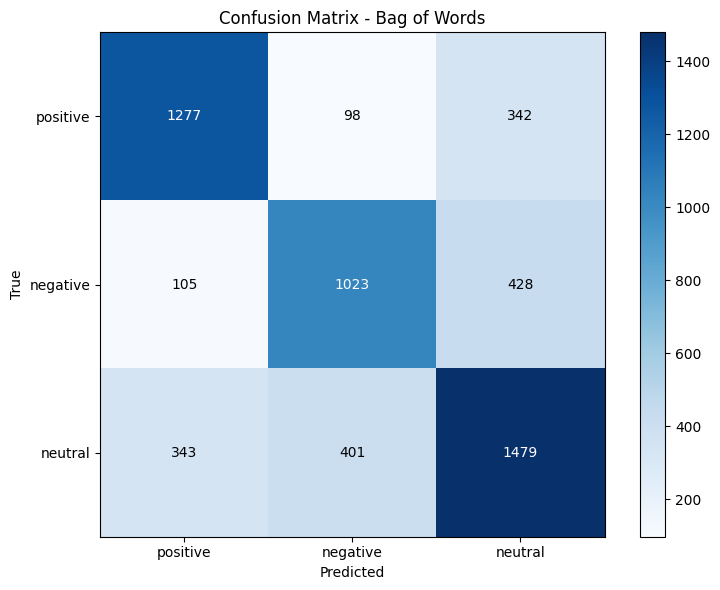

In [ ]:
# Создаем векторизатор
count_vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)

print(f"Размерность BoW: {X_train_counts.shape}")

# Обучаем модель
clf_bow = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
clf_bow.fit(X_train_counts, y_train)

# Предсказания
y_pred_bow = clf_bow.predict(X_test_counts)

# Метрики
accuracy_bow = accuracy_score(y_test, y_pred_bow)
precision_bow = precision_score(y_test, y_pred_bow, average='weighted')
recall_bow = recall_score(y_test, y_pred_bow, average='weighted')
f1_bow = f1_score(y_test, y_pred_bow, average='weighted')

print(f"Accuracy:  {accuracy_bow:.4f}")
print(f"Precision: {precision_bow:.4f}")
print(f"Recall:    {recall_bow:.4f}")
print(f"F1-score:  {f1_bow:.4f}")

# Confusion Matrix
cm_bow = confusion_matrix(y_test, y_pred_bow)
plt.figure(figsize=(8, 6))
plt.imshow(cm_bow, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - Bag of Words')
plt.colorbar()
tick_marks = np.arange(3)
plt.xticks(tick_marks, ['positive', 'negative', 'neutral'])
plt.yticks(tick_marks, ['positive', 'negative', 'neutral'])
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm_bow[i, j], ha='center', va='center', color='white' if cm_bow[i, j] > cm_bow.max()/2 else 'black')
plt.tight_layout()
plt.show()

(0.0, 1.0)

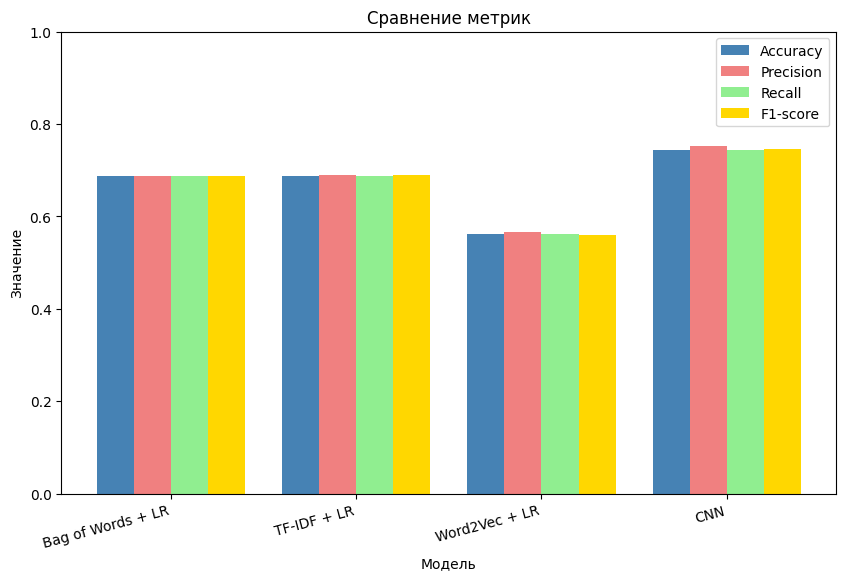

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results['Модель']))
width = 0.2

ax.bar(x - 1.5*width, results['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x - 0.5*width, results['Precision'], width, label='Precision', color='lightcoral')
ax.bar(x + 0.5*width, results['Recall'], width, label='Recall', color='lightgreen')
ax.bar(x + 1.5*width, results['F1-score'], width, label='F1-score', color='gold')

ax.set_xlabel('Модель')
ax.set_ylabel('Значение')
ax.set_title('Сравнение метрик')
ax.set_xticks(x)
ax.set_xticklabels(results['Модель'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)

In [ ]:
best_model_name = results.loc[results['F1-score'].idxmax(), 'Модель']
print(f"Лучшая модель: {best_model_name}")

n_examples = 5
indices = np.random.choice(len(X_test), n_examples, replace=False)

for i, idx in enumerate(indices):
    text = X_test[idx]
    true_label = label_to_text[y_test[idx]]


    print(f"Пример {i+1}:")
    print(f"Текст: {text}")
    print(f"True: {true_label}")
    print(f"Pred: {pred_label} (confidence: {confidence:.3f})")
    print(f"Вероятности: positive={pred_proba[0]:.3f}, negative={pred_proba[1]:.3f}, neutral={pred_proba[2]:.3f}")

Лучшая модель: CNN
Пример 1:
Текст: its ok because one of my favorite movie series is star wars that makes me more of a dork than you
True: positive
Pred: neutral (confidence: 0.755)
Вероятности: positive=0.192, negative=0.053, neutral=0.755
Пример 2:
Текст: there is no sale in botega
True: neutral
Pred: neutral (confidence: 0.755)
Вероятности: positive=0.192, negative=0.053, neutral=0.755
Пример 3:
Текст: first year in ages where im not going to the crafty raft o i dont mind though i dont even like the crafty raft
True: negative
Pred: neutral (confidence: 0.755)
Вероятности: positive=0.192, negative=0.053, neutral=0.755
Пример 4:
Текст: hummmmm ohh i miss you so much realy but i hope you have a nice friends like us
True: neutral
Pred: neutral (confidence: 0.755)
Вероятности: positive=0.192, negative=0.053, neutral=0.755
Пример 5:
Текст: word
True: neutral
Pred: neutral (confidence: 0.755)
Вероятности: positive=0.192, negative=0.053, neutral=0.755
